In [1]:
%cd /home/raman/school/CMPT_459/project/cmpt-459-project

/home/raman/school/CMPT_459/project/cmpt-459-project


/home/raman/school/CMPT_459/project/cmpt-459-project/cpython_env/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [5]:
from utils.enums import Ticker, TimeFrame
from feature_extraction.feature_extractor import extract_features_from_bias_node
from utils.pca_analysis import perform_pca_analysis, get_top_features_per_component

In [3]:
# Generate RSI specs for lookbacks 2-20
lookbacks = range(2, 21)  
rsi_specs = [
    {
        'module_name': 'rsi',
        'timeframes': [TimeFrame.D],
        'params': {'lookback': lb}
    }
    for lb in lookbacks
]
ticker_list = [Ticker.ES, Ticker.NQ, Ticker.YM, Ticker.RTY]

# Extract all at once
features_df, targets_df = extract_features_from_bias_node(
    ticker=ticker_list,
    bias_node_specs=rsi_specs
)


✓ Cython node optimizations loaded (5-10x speedup for ATR, EMA, etc.)


Running backtest features:   0%|          | 2/7094 [00:00<23:01,  5.13candles/s]/home/raman/school/CMPT_459/project/cmpt-459-project/feature_extraction/ml_manager.py:121: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  self.matrix = pd.concat([self.matrix, buffer_df])
/home/raman/school/CMPT_459/project/cmpt-459-project/feature_extraction/ml_manager.py:121: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.matrix = pd.concat([self.matrix, buffer_df])
Running backtest features:   0%|          | 0/6643 [00:00<?, ?candles/s]/hom

In [4]:
features_df

,atr_252_D_atr_252,atr_252_D_atr_pct_252,ewsd_252_D_ewsd_daily_pct,ewsd_252_D_ewsd_annual_pct,rsi_10_D_rsi_10,rsi_11_D_rsi_11,rsi_12_D_rsi_12,rsi_13_D_rsi_13,rsi_14_D_rsi_14,rsi_15_D_rsi_15,...,rsi_2_D_rsi_2,rsi_20_D_rsi_20,rsi_3_D_rsi_3,rsi_4_D_rsi_4,rsi_5_D_rsi_5,rsi_6_D_rsi_6,rsi_7_D_rsi_7,rsi_8_D_rsi_8,rsi_9_D_rsi_9,ticker
1997-09-09 00:00:00+00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,ES
1997-09-10 00:00:00+00:00,8.500000,0.910064,1.000000,16.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,...,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,ES
1997-09-11 00:00:00+00:00,14.125000,1.543294,1.705246,27.283940,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,...,98.032013,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,ES
1997-09-12 00:00:00+00:00,15.916667,1.733370,0.711269,11.380301,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,...,98.044329,50.000000,98.038190,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,ES
1997-09-15 00:00:00+00:00,17.687500,1.894041,1.457053,23.312846,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,...,98.163835,50.000000,98.085074,98.069697,50.000000,50.000000,50.000000,50.000000,50.000000,ES
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-18 00:00:00.003000+00:00,46.766669,1.926933,0.635838,10.173401,65.742665,65.478851,65.217503,64.962722,64.717025,64.481557,...,72.716961,63.444447,68.890311,67.655681,67.093002,66.762123,66.503731,66.257009,66.003627,RTY
2025-09-19 00:00:00+00:00,86.067460,1.285836,0.709648,11.354368,74.812617,73.808050,72.934817,72.174235,71.508868,70.923098,...,86.350806,68.775551,84.847884,83.697485,82.118165,80.412511,78.775343,77.286400,75.967029,ES
2025-09-19 00:00:00.001000+00:00,399.884921,1.618607,1.113297,17.812746,77.039420,75.689862,74.513339,73.488982,72.595814,71.814329,...,89.571651,69.048765,88.705487,87.826595,86.221397,84.253990,82.230721,80.315891,78.579279,NQ
2025-09-19 00:00:00.002000+00:00,596.857143,1.283122,0.561654,8.986465,67.415342,66.829741,66.309306,65.843026,65.422463,65.040680,...,85.724956,63.532668,78.355776,74.709896,72.476425,70.934975,69.779054,68.855120,68.081987,YM


PCA Analysis
Number of samples: 21748
Number of features: 23
Features standardized: Yes
Number of components: 20
Total variance explained by 20 components: 100.00%

Top 5 components explain: 98.74%
Top features for PC1:
           feature   loading  abs_loading
0  rsi_10_D_rsi_10  0.238378     0.238378
1  rsi_11_D_rsi_11  0.238285     0.238285
2    rsi_9_D_rsi_9  0.237850     0.237850
3  rsi_12_D_rsi_12  0.237713     0.237713
4  rsi_13_D_rsi_13  0.236770     0.236770
5    rsi_8_D_rsi_8  0.236508     0.236508
6  rsi_14_D_rsi_14  0.235533     0.235533
7    rsi_7_D_rsi_7  0.234072     0.234072
8  rsi_15_D_rsi_15  0.234050     0.234050
9  rsi_16_D_rsi_16  0.232356     0.232356

First 5 components explain: 98.74% of variance

Top 5 features on PC1:
rsi_10_D_rsi_10    0.238378
rsi_11_D_rsi_11    0.238285
rsi_9_D_rsi_9      0.237850
rsi_12_D_rsi_12    0.237713
rsi_13_D_rsi_13    0.236770
Name: PC1, dtype: float64


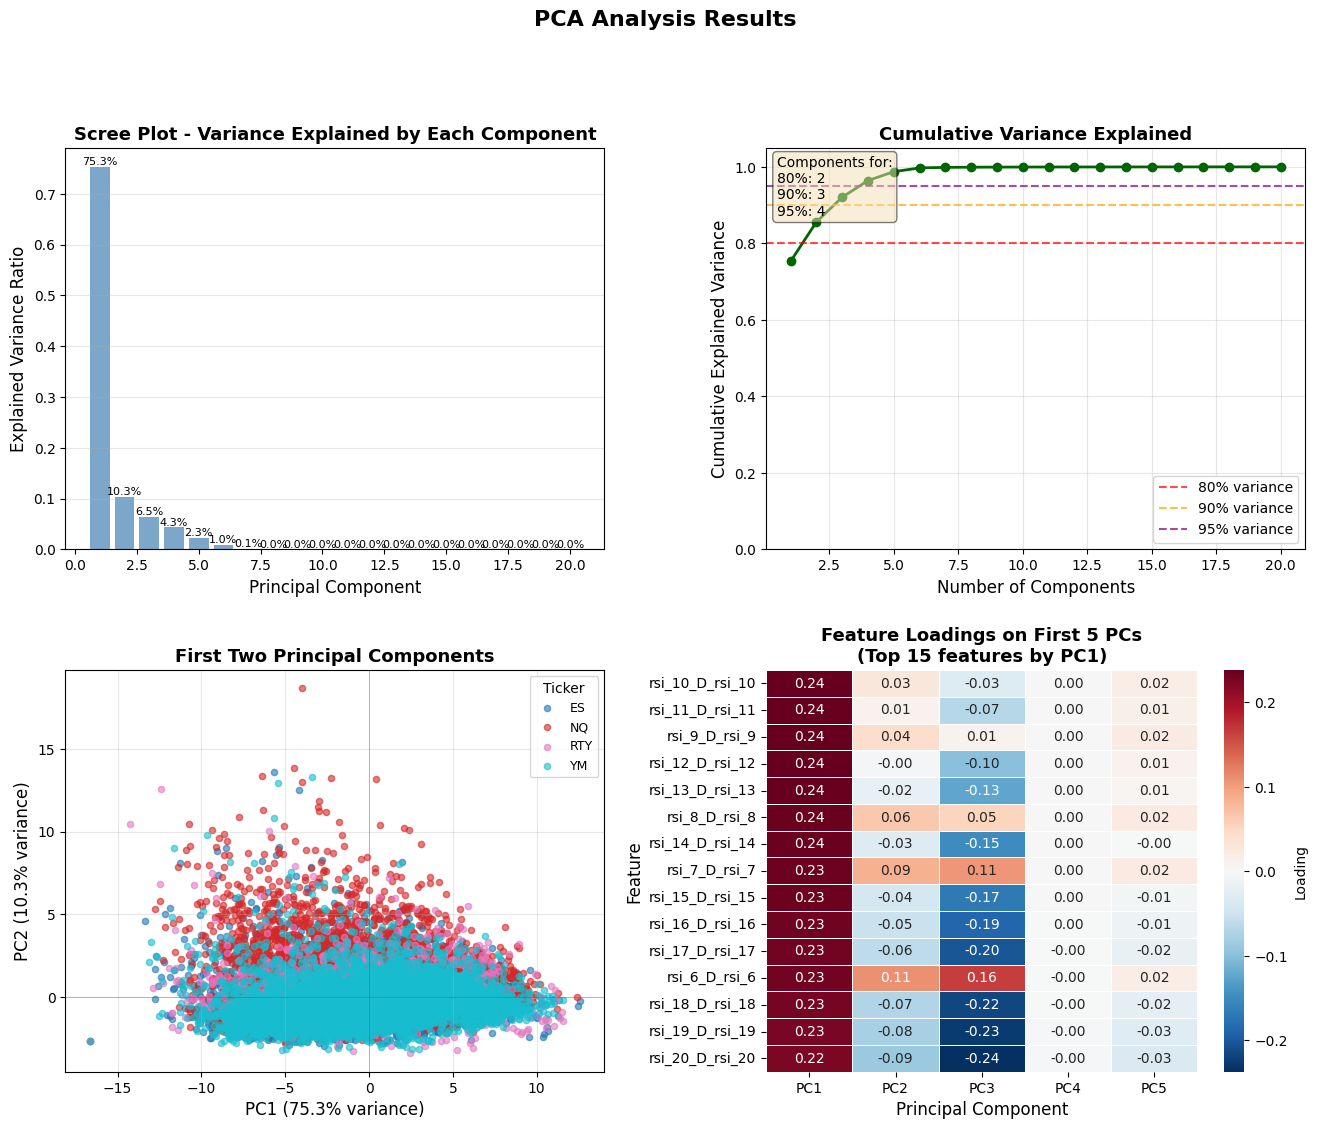

In [6]:

# Perform PCA and create visualizations
pca, transformed, loadings = perform_pca_analysis(
    features_df,
    exclude_columns=['ticker'],  # Exclude non-feature columns
    n_components=20,
    standardize=True,
    plot=True
)

# Get top features for each component
top_features = get_top_features_per_component(loadings, n_components=5, n_features=10)
print("Top features for PC1:")
print(top_features['PC1'])

# Access PCA results
print(f"\nFirst 5 components explain: {pca.explained_variance_ratio_[:5].sum():.2%} of variance")
print(f"\nTop 5 features on PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head())